# Basics of Neural networks and other stuff
In this exercise you will experience working with keras, a useful tool for designing and training neural networks.

~Ittai Haran

---

# Going Deeper — completed neural-network exercise

## Guidelines applied throughout

1. **Reproducibility:** one global seed (42), deterministic TensorFlow operations, explicit train/validation/test partitions, and named experiment configurations.
2. **Data discipline:** the supplied CSV files are used directly; 30% is held out once for testing, and 20% of the remaining development data is used for validation.
3. **Fair comparisons:** architecture studies keep the split, seed, loss, and stopping rule fixed while changing only the stated factor. Validation loss selects configurations; test data is used only for final reporting.
4. **Model selection:** regression experiments use mean-squared error. Classification reports loss, accuracy, balanced accuracy, macro one-vs-rest AUC, and a confusion matrix.
5. **Modern APIs:** TensorFlow 2.21 / Keras 3 functional models, `keras.ops`, callbacks, and `tf.GradientTape`; no private or removed Keras backend methods.
6. **Hardware-aware execution:** this Windows machine has an Intel Core Ultra 7 165H (16 cores / 22 threads), about 63 GB RAM, and integrated Intel Arc Pro graphics with 2 GB reported adapter memory. Native TensorFlow has no supported CUDA device here, so training uses the CPU with oneDNN, large vectorized batches, early stopping, and a 20,000-row search subset for the largest architecture sweep.
7. **Efficiency:** NumPy vectorization is used for the 600×600 loss surfaces; the 100,000-row periodic dataset is fully used only for the winning configuration.
8. **Observability:** important decisions, metrics, timing, output locations, and hardware devices are logged; plots are both displayed and saved.
9. **Quality gates:** function-1 test MSE ≤ 1e-3; function-2 test MSE ≤ 1e-4; function-3 test MSE ≤ 1e-2; informed sine test MSE ≤ 1e-4; MNIST accuracy ≥ 0.97 and macro OvR AUC ≥ 0.995; shallow identity MSE ≤ 1e-3; the 50-layer sigmoid model performs worse and has a first-layer maximum absolute gradient ≤ 1e-6.
10. **Artifacts:** figures are saved as PNG files and tabular results are exported to a timestamped Excel workbook after notebook execution.

## Stage 1- predicting engineered functions
Here you will design a simple fully connected network to predict a few simple functions. You will try different activation functions and different architectures (number of layers, size of layers).

---

## Stage 1 — predicting engineered functions

Each regression experiment loads the supplied data, makes the same deterministic 70% development / 30% test split, and reserves 20% of the development partition for validation. The test partition remains untouched until a configuration has been selected.

The first experiment will be guided:
- Read the first dataframe - function_1.csv. (in: https://drive.google.com/open?id=19Y9f2pkUwP7nrgbKCmCGHEomHmA0pwqx)
- Plot y against x. can you guess the function y(x)?
- Split you data to train segment (70%) and test segment (30%).
- Write a fully connected neural network with one hidden layer with 3 units. I suggest using the [functional API](https://keras.io/getting-started/functional-api-guide/) - you can also find there examples for simple working with keras.
- Use tanh as an activation function for the hidden layer and a linear activation for the output layer.
- Use model.summary() to look at your model's architecture.
- Use mean squared error as the loss function and SGD (stochastic gradient descent) as the optimizer.
- Try training the network with different batch's sizes (don't be afraid to use many epochs- you don't have a lot of data).
- Plot y against x and f(x) against x on the same graph.
- Compute the loss on the test segment.
- Can you use a smaller hidden layer?

---

### Function 1: batch size and minimum hidden width

The observed relationship is $y=x^2$. First compare batch sizes 5, 32, and 128 using the required one-hidden-layer, three-unit tanh network with SGD. Then compare widths 1, 2, and 3 at batch size 32. The smallest width whose validation MSE is within 10% of the three-unit reference is selected and evaluated on the held-out test set.

In [1]:
from __future__ import annotations

from collections.abc import Callable
from pathlib import Path
from time import perf_counter
from typing import Any
import json
import os

from going_deeper_init import (
    EXERCISE_DIRECTORY,
    LOGGER,
    OUTPUT_DIRECTORY,
    RANDOM_SEED,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.metrics import confusion_matrix, roc_auc_score
from tensorflow import keras

tf.config.threading.set_intra_op_parallelism_threads(num_threads=min(os.cpu_count() or 1, 16))
tf.config.threading.set_inter_op_parallelism_threads(num_threads=2)
keras.utils.set_random_seed(seed=RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

METRIC_RECORDS: list[dict[str, Any]] = []
TIMING_RECORDS: list[dict[str, Any]] = []
FIGURE_PATHS: list[Path] = []

LOGGER.info("TensorFlow version: %s; Keras version: %s", tf.__version__, keras.__version__)
LOGGER.info("Logical devices: %s", [device.name for device in tf.config.list_logical_devices()])
LOGGER.info("CPU threads available: %s; training mode: CPU/oneDNN", os.cpu_count())


def split_regression_data(
    *,
    features: np.ndarray,
    targets: np.ndarray,
    test_fraction: float = 0.30,
    validation_fraction_of_development: float = 0.20,
    seed: int = RANDOM_SEED,
) -> dict[str, np.ndarray]:
    """Create deterministic train, validation, and held-out test partitions.

    Args:
        features: Two-dimensional model features.
        targets: Two-dimensional regression targets.
        test_fraction: Fraction reserved for final testing.
        validation_fraction_of_development: Fraction of development data for validation.
        seed: Random seed used for shuffling.

    Returns:
        Mapping containing X_train, y_train, X_validation, y_validation,
        X_test, and y_test.
    """
    if features.ndim != 2 or targets.ndim != 2:
        raise ValueError("features and targets must both be two-dimensional")
    if features.shape[0] != targets.shape[0]:
        raise ValueError("features and targets must contain the same number of rows")

    random_generator = np.random.default_rng(seed=seed)
    shuffled_indices = random_generator.permutation(x=features.shape[0])
    number_of_test_rows = int(round(features.shape[0] * test_fraction))
    test_indices = shuffled_indices[:number_of_test_rows]
    development_indices = shuffled_indices[number_of_test_rows:]
    number_of_validation_rows = int(
        round(development_indices.size * validation_fraction_of_development)
    )
    validation_indices = development_indices[:number_of_validation_rows]
    train_indices = development_indices[number_of_validation_rows:]
    return {
        "X_train": features[train_indices],
        "y_train": targets[train_indices],
        "X_validation": features[validation_indices],
        "y_validation": targets[validation_indices],
        "X_test": features[test_indices],
        "y_test": targets[test_indices],
    }


def build_regressor(
    *,
    hidden_units: tuple[int, ...],
    activation: str | Callable[[tf.Tensor], tf.Tensor],
    optimizer: keras.optimizers.Optimizer,
    seed: int,
    model_name: str,
) -> keras.Model:
    """Build and compile a one-input regression model.

    Args:
        hidden_units: Units in each hidden layer.
        activation: Hidden-layer activation.
        optimizer: Configured Keras optimizer.
        seed: Seed used by kernel initializers.
        model_name: Descriptive model name.

    Returns:
        Compiled Keras regression model.
    """
    keras.utils.set_random_seed(seed=seed)
    model_input = keras.Input(shape=(1,), name="x")
    layer_output = model_input
    for layer_number, number_of_units in enumerate(hidden_units):
        layer_output = keras.layers.Dense(
            units=number_of_units,
            activation=activation,
            kernel_initializer=keras.initializers.GlorotUniform(
                seed=seed + layer_number
            ),
            name=f"hidden_{layer_number + 1}",
        )(layer_output)
    model_output = keras.layers.Dense(
        units=1,
        activation="linear",
        kernel_initializer=keras.initializers.GlorotUniform(
            seed=seed + len(hidden_units)
        ),
        name="prediction",
    )(layer_output)
    model = keras.Model(inputs=model_input, outputs=model_output, name=model_name)
    model.compile(optimizer=optimizer, loss="mse")
    return model


def fit_regressor(
    *,
    model: keras.Model,
    data_partitions: dict[str, np.ndarray],
    batch_size: int,
    maximum_epochs: int,
    patience: int,
) -> tuple[keras.callbacks.History, float]:
    """Fit a regressor with early stopping and return validation MSE.

    Args:
        model: Compiled Keras model.
        data_partitions: Train, validation, and test arrays.
        batch_size: Mini-batch size.
        maximum_epochs: Maximum number of epochs.
        patience: Early-stopping patience.

    Returns:
        Training history and best validation MSE.
    """
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=patience,
        min_delta=1e-8,
        restore_best_weights=True,
    )
    history = model.fit(
        x=data_partitions["X_train"],
        y=data_partitions["y_train"],
        validation_data=(
            data_partitions["X_validation"],
            data_partitions["y_validation"],
        ),
        batch_size=batch_size,
        epochs=maximum_epochs,
        callbacks=[early_stopping],
        verbose=0,
        shuffle=True,
    )
    best_validation_mse = float(np.min(a=np.asarray(history.history["val_loss"])))
    return history, best_validation_mse


def save_figure(*, figure: plt.Figure, file_name: str) -> Path:
    """Save and register a figure.

    Args:
        figure: Matplotlib figure to save.
        file_name: PNG file name.

    Returns:
        Absolute path to the saved figure.
    """
    figure_path = OUTPUT_DIRECTORY / file_name
    figure.savefig(
        fname=figure_path,
        dpi=160,
        bbox_inches="tight",
        facecolor="white",
    )
    FIGURE_PATHS.append(figure_path)
    LOGGER.info("Saved figure: %s", figure_path)
    return figure_path


# Focused helper tests.
_test_features = np.arange(10, dtype=np.float32).reshape((-1, 1))
_test_targets = _test_features.copy()
_test_partitions = split_regression_data(
    features=_test_features,
    targets=_test_targets,
    test_fraction=0.30,
    validation_fraction_of_development=0.20,
    seed=RANDOM_SEED,
)
assert sum(partition.shape[0] for name, partition in _test_partitions.items() if name.startswith("X_")) == 10
_test_model = build_regressor(
    hidden_units=(3,),
    activation="tanh",
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    seed=RANDOM_SEED,
    model_name="helper_test",
)
assert _test_model.output_shape == (None, 1)
del _test_model, _test_features, _test_targets, _test_partitions

2026-09-06 18:03:29,424 | INFO | going_deeper | Output directory: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329
2026-09-06 18:03:34,276 | INFO | going_deeper | TensorFlow version: 2.21.0; Keras version: 3.15.1
2026-09-06 18:03:34,280 | INFO | going_deeper | Logical devices: ['/device:CPU:0']
2026-09-06 18:03:34,281 | INFO | going_deeper | CPU threads available: 22; training mode: CPU/oneDNN
2026-09-06 18:03:34,350 | WARNING | tensorflow | TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


2026-09-06 18:03:34,566 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\function_1_data.png


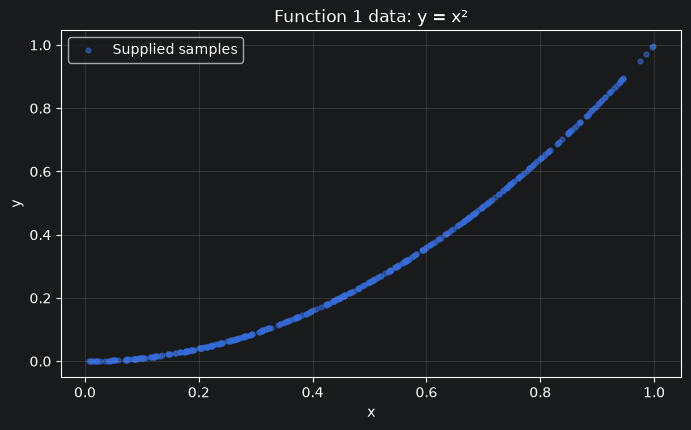

2026-09-06 18:04:21,924 | INFO | going_deeper | Function 1 | batch_5_units_3 | val MSE 0.00001696 | epochs 35 | 47.3s
2026-09-06 18:04:55,021 | INFO | going_deeper | Function 1 | batch_32_units_3 | val MSE 0.00001273 | epochs 160 | 33.1s
2026-09-06 18:05:12,662 | INFO | going_deeper | Function 1 | batch_128_units_3 | val MSE 0.00001358 | epochs 160 | 17.6s
2026-09-06 18:05:46,087 | INFO | going_deeper | Function 1 | batch_32_units_1 | val MSE 0.00002158 | epochs 160 | 33.4s
2026-09-06 18:06:18,946 | INFO | going_deeper | Function 1 | batch_32_units_2 | val MSE 0.00001740 | epochs 160 | 32.9s


,name,hidden_units,batch_size,validation_mse,epochs,elapsed_seconds
1,batch_32_units_3,3,32,0.000013,160,33.095330
2,batch_128_units_3,3,128,0.000014,160,17.640449
0,batch_5_units_3,3,5,0.000017,35,47.283645
4,batch_32_units_2,2,32,0.000017,160,32.857644
3,batch_32_units_1,1,32,0.000022,160,33.423846


2026-09-06 18:06:19,264 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\function_1_fit.png


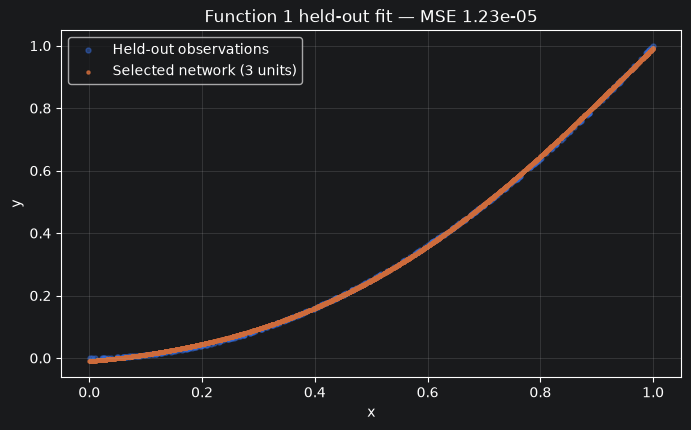

2026-09-06 18:06:19,355 | INFO | going_deeper | Function 1 selected batch_32_units_3; held-out MSE 0.00001234


In [2]:
function_1_frame = pd.read_csv(
    filepath_or_buffer=EXERCISE_DIRECTORY / "function_1.csv",
    dtype={"x": np.float32, "y": np.float32},
)
function_1_features = function_1_frame.loc[:, ["x"]].to_numpy(dtype=np.float32)
function_1_targets = function_1_frame.loc[:, ["y"]].to_numpy(dtype=np.float32)
function_1_partitions = split_regression_data(
    features=function_1_features,
    targets=function_1_targets,
)

function_1_figure, function_1_axis = plt.subplots(figsize=(8, 4.5))
function_1_axis.scatter(
    x=function_1_features[::25, 0],
    y=function_1_targets[::25, 0],
    s=12,
    alpha=0.55,
    label="Supplied samples",
)
function_1_axis.set(
    title="Function 1 data: y = x²",
    xlabel="x",
    ylabel="y",
)
function_1_axis.grid(visible=True, alpha=0.25)
function_1_axis.legend()
save_figure(figure=function_1_figure, file_name="function_1_data.png")
plt.show()

function_1_configurations = [
    {"name": "batch_5_units_3", "hidden_units": 3, "batch_size": 5},
    {"name": "batch_32_units_3", "hidden_units": 3, "batch_size": 32},
    {"name": "batch_128_units_3", "hidden_units": 3, "batch_size": 128},
    {"name": "batch_32_units_1", "hidden_units": 1, "batch_size": 32},
    {"name": "batch_32_units_2", "hidden_units": 2, "batch_size": 32},
]
function_1_results: list[dict[str, Any]] = []
function_1_models: dict[str, keras.Model] = {}

for configuration_number, configuration in enumerate(function_1_configurations):
    experiment_start = perf_counter()
    configured_model = build_regressor(
        hidden_units=(configuration["hidden_units"],),
        activation="tanh",
        optimizer=keras.optimizers.SGD(
            learning_rate=0.05,
            momentum=0.90,
        ),
        seed=RANDOM_SEED + configuration_number,
        model_name=configuration["name"],
    )
    configured_history, validation_mse = fit_regressor(
        model=configured_model,
        data_partitions=function_1_partitions,
        batch_size=configuration["batch_size"],
        maximum_epochs=(
            35 if configuration["batch_size"] == 5 else 160
        ),
        patience=(
            8 if configuration["batch_size"] == 5 else 20
        ),
    )
    elapsed_seconds = perf_counter() - experiment_start
    function_1_models[configuration["name"]] = configured_model
    function_1_results.append(
        {
            **configuration,
            "validation_mse": validation_mse,
            "epochs": len(configured_history.history["loss"]),
            "elapsed_seconds": elapsed_seconds,
        }
    )
    LOGGER.info(
        "Function 1 | %s | val MSE %.8f | epochs %d | %.1fs",
        configuration["name"],
        validation_mse,
        len(configured_history.history["loss"]),
        elapsed_seconds,
    )

function_1_results_frame = pd.DataFrame(data=function_1_results).sort_values(
    by="validation_mse"
)
display(function_1_results_frame)

reference_validation_mse = next(
    result["validation_mse"]
    for result in function_1_results
    if result["name"] == "batch_32_units_3"
)
width_candidates = [
    result
    for result in function_1_results
    if result["batch_size"] == 32
    and result["validation_mse"] <= 1.10 * reference_validation_mse
]
selected_function_1_result = min(
    width_candidates,
    key=lambda result: result["hidden_units"],
)
selected_function_1_model = function_1_models[selected_function_1_result["name"]]
function_1_test_mse = float(
    selected_function_1_model.evaluate(
        x=function_1_partitions["X_test"],
        y=function_1_partitions["y_test"],
        batch_size=128,
        verbose=0,
    )
)
function_1_predictions = selected_function_1_model.predict(
    x=function_1_partitions["X_test"],
    batch_size=128,
    verbose=0,
).reshape((-1,))
function_1_sort_order = np.argsort(a=function_1_partitions["X_test"][:, 0])

function_1_fit_figure, function_1_fit_axis = plt.subplots(figsize=(8, 4.5))
function_1_fit_axis.scatter(
    x=function_1_partitions["X_test"][::10, 0],
    y=function_1_partitions["y_test"][::10, 0],
    s=13,
    alpha=0.45,
    label="Held-out observations",
)
function_1_fit_axis.scatter(
    x=function_1_partitions["X_test"][function_1_sort_order, 0],
    y=function_1_predictions[function_1_sort_order],
    s=5,
    alpha=0.8,
    label=f"Selected network ({selected_function_1_result['hidden_units']} units)",
)
function_1_fit_axis.set(
    title=f"Function 1 held-out fit — MSE {function_1_test_mse:.2e}",
    xlabel="x",
    ylabel="y",
)
function_1_fit_axis.grid(visible=True, alpha=0.25)
function_1_fit_axis.legend()
save_figure(figure=function_1_fit_figure, file_name="function_1_fit.png")
plt.show()

METRIC_RECORDS.append(
    {
        "stage": "Function 1",
        "experiment": selected_function_1_result["name"],
        "metric": "test_mse",
        "value": function_1_test_mse,
        "threshold": 1e-3,
        "passed": function_1_test_mse <= 1e-3,
    }
)
for experiment_result in function_1_results:
    TIMING_RECORDS.append(
        {
            "stage": "Function 1",
            "experiment": experiment_result["name"],
            "epochs": experiment_result["epochs"],
            "elapsed_seconds": experiment_result["elapsed_seconds"],
        }
    )
LOGGER.info(
    "Function 1 selected %s; held-out MSE %.8f",
    selected_function_1_result["name"],
    function_1_test_mse,
)

In [3]:
# Preserve the original section-ending report format.
display(
    Markdown(
        f"""```text
loss on test segment: {function_1_test_mse:.12g}
```"""
    )
)

```text
loss on test segment: 1.23376958072e-05
```

For the second experiment use the dataframe function_2.csv. Here you might need to have more layers. You might want to consider different [optimizers](https://keras.io/optimizers/), rather than SGD (for example, Adam).

(function_2.csv can be found in: https://drive.google.com/open?id=1Fk32cP-4DSZ6v175UDVz_OChHE-dFLzq)

---

### Function 2: depth comparison

For the supplied second function, compare tanh networks with hidden-layer layouts ((3)), ((3,3)), and ((3,3,3,3)). All use Adam, batch size 128, the same split, and the same early-stopping rule. Select by validation MSE and report the winner once on the held-out test set.

2026-09-06 18:06:39,549 | INFO | going_deeper | Function 2 | 3 | val MSE 0.00000979 | epochs 131 | 20.1s
2026-09-06 18:07:45,172 | INFO | going_deeper | Function 2 | 3x3 | val MSE 0.00000004 | epochs 500 | 65.6s
2026-09-06 18:08:05,530 | INFO | going_deeper | Function 2 | 3x3x3x3 | val MSE 0.00001907 | epochs 177 | 20.4s


,architecture,depth,validation_mse,epochs,elapsed_seconds
1,3x3,2,3.679340e-08,500,65.622184
0,3,1,9.794644e-06,131,20.107549
2,3x3x3x3,4,1.906925e-05,177,20.357317


2026-09-06 18:08:05,857 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\function_2_fit.png


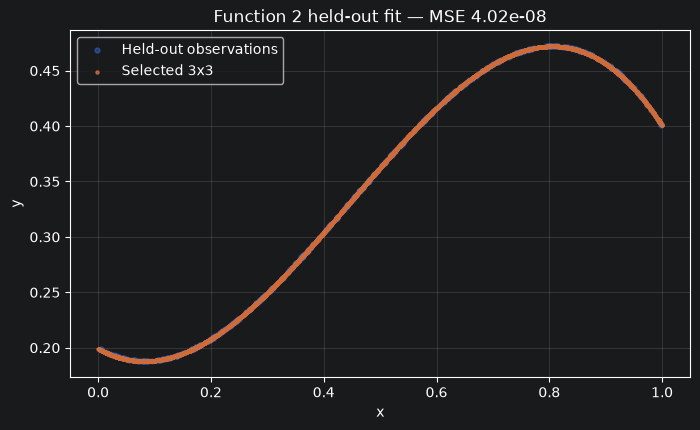

2026-09-06 18:08:05,945 | INFO | going_deeper | Function 2 selected 3x3; held-out MSE 0.00000004


In [4]:
function_2_frame = pd.read_csv(
    filepath_or_buffer=EXERCISE_DIRECTORY / "function_2.csv",
    dtype={"x": np.float32, "y": np.float32},
)
function_2_features = function_2_frame.loc[:, ["x"]].to_numpy(dtype=np.float32)
function_2_targets = function_2_frame.loc[:, ["y"]].to_numpy(dtype=np.float32)
function_2_partitions = split_regression_data(
    features=function_2_features,
    targets=function_2_targets,
)

function_2_architectures = ((3,), (3, 3), (3, 3, 3, 3))
function_2_results: list[dict[str, Any]] = []
function_2_models: dict[str, keras.Model] = {}

for architecture_number, hidden_architecture in enumerate(function_2_architectures):
    architecture_name = "x".join(str(number_of_units) for number_of_units in hidden_architecture)
    experiment_start = perf_counter()
    configured_model = build_regressor(
        hidden_units=hidden_architecture,
        activation="tanh",
        optimizer=keras.optimizers.Adam(learning_rate=0.005),
        seed=RANDOM_SEED + 100 + architecture_number,
        model_name=f"function_2_{architecture_name}",
    )
    configured_history, validation_mse = fit_regressor(
        model=configured_model,
        data_partitions=function_2_partitions,
        batch_size=128,
        maximum_epochs=500,
        patience=45,
    )
    elapsed_seconds = perf_counter() - experiment_start
    function_2_models[architecture_name] = configured_model
    function_2_results.append(
        {
            "architecture": architecture_name,
            "depth": len(hidden_architecture),
            "validation_mse": validation_mse,
            "epochs": len(configured_history.history["loss"]),
            "elapsed_seconds": elapsed_seconds,
        }
    )
    LOGGER.info(
        "Function 2 | %s | val MSE %.8f | epochs %d | %.1fs",
        architecture_name,
        validation_mse,
        len(configured_history.history["loss"]),
        elapsed_seconds,
    )

function_2_results_frame = pd.DataFrame(data=function_2_results).sort_values(
    by="validation_mse"
)
display(function_2_results_frame)
selected_function_2_result = function_2_results_frame.iloc[0].to_dict()
selected_function_2_model = function_2_models[selected_function_2_result["architecture"]]
function_2_test_mse = float(
    selected_function_2_model.evaluate(
        x=function_2_partitions["X_test"],
        y=function_2_partitions["y_test"],
        batch_size=256,
        verbose=0,
    )
)
function_2_predictions = selected_function_2_model.predict(
    x=function_2_partitions["X_test"],
    batch_size=256,
    verbose=0,
).reshape((-1,))
function_2_sort_order = np.argsort(a=function_2_partitions["X_test"][:, 0])

function_2_figure, function_2_axis = plt.subplots(figsize=(8, 4.5))
function_2_axis.scatter(
    x=function_2_partitions["X_test"][::10, 0],
    y=function_2_partitions["y_test"][::10, 0],
    s=13,
    alpha=0.45,
    label="Held-out observations",
)
function_2_axis.scatter(
    x=function_2_partitions["X_test"][function_2_sort_order, 0],
    y=function_2_predictions[function_2_sort_order],
    s=5,
    alpha=0.8,
    label=f"Selected {selected_function_2_result['architecture']}",
)
function_2_axis.set(
    title=f"Function 2 held-out fit — MSE {function_2_test_mse:.2e}",
    xlabel="x",
    ylabel="y",
)
function_2_axis.grid(visible=True, alpha=0.25)
function_2_axis.legend()
save_figure(figure=function_2_figure, file_name="function_2_fit.png")
plt.show()

METRIC_RECORDS.append(
    {
        "stage": "Function 2",
        "experiment": selected_function_2_result["architecture"],
        "metric": "test_mse",
        "value": function_2_test_mse,
        "threshold": 1e-4,
        "passed": function_2_test_mse <= 1e-4,
    }
)
for experiment_result in function_2_results:
    TIMING_RECORDS.append(
        {
            "stage": "Function 2",
            "experiment": experiment_result["architecture"],
            "epochs": experiment_result["epochs"],
            "elapsed_seconds": experiment_result["elapsed_seconds"],
        }
    )
LOGGER.info(
    "Function 2 selected %s; held-out MSE %.8f",
    selected_function_2_result["architecture"],
    function_2_test_mse,
)

In [5]:
# Preserve the original section-ending report format.
display(
    Markdown(
        f"""```text
loss on test segment: {function_2_test_mse:.12g}
```"""
    )
)

```text
loss on test segment: 4.02166335789e-08
```

For the third experiment use the dataframe function_3.csv. Try different activation functions. How many layers you had to take?

(function_3.csv can be found in: https://drive.google.com/open?id=1-XTfy6Wf0_WhEKJ9AnUGENBZRSNXkwNe)

---

### Function 3: activation × depth search

The supplied target is (y=sin(2pi x)). Compare tanh, ReLU, and sigmoid at depths 1, 2, and 4, using width 32 and batch size 512. To respect the CPU-only environment, configuration search uses a fixed seeded 20,000-row training subset. The validation winner is then retrained on the full development training partition and evaluated once on the 30% test partition.

As you maybe could've guessed, the function you fitted is $y = sin(x)$. Hence one might think it would be easy to fit a network with only one neuron, with activation of the sinus function. Try it: define a neural network with a single input and a single output, with no hidden layers, and use a sinus activation, to approximate function_3. Next we will understand why using sinus as an activation function is not a good idea.

You can use sin_activation provided below as the sinus activation: instead of writing activation='tanh' or activation='sigmoid', use activation=sin_activation.

---

### A single sinusoidal neuron

The supplied periodic target is $y=\sin(2\pi x)$. A single neuron with sine activation can represent it exactly as (sin(ax+b)), but the periodic loss surface contains many basins and stationary regions. Compare a default random initialization with an informed initialization (a=2pi, b=0).

2026-09-06 18:08:27,718 | INFO | going_deeper | Function 3 search | tanh_depth_1 | val MSE 0.44297108 | epochs 120 | 21.7s
2026-09-06 18:08:48,551 | INFO | going_deeper | Function 3 search | tanh_depth_2 | val MSE 0.23116915 | epochs 120 | 20.8s
2026-09-06 18:09:06,338 | INFO | going_deeper | Function 3 search | tanh_depth_4 | val MSE 0.00014994 | epochs 120 | 17.8s
2026-09-06 18:09:21,397 | INFO | going_deeper | Function 3 search | relu_depth_1 | val MSE 0.47045174 | epochs 120 | 15.1s
2026-09-06 18:09:36,717 | INFO | going_deeper | Function 3 search | relu_depth_2 | val MSE 0.27012494 | epochs 120 | 15.3s
2026-09-06 18:09:51,495 | INFO | going_deeper | Function 3 search | relu_depth_4 | val MSE 0.02347319 | epochs 106 | 14.8s
2026-09-06 18:10:06,417 | INFO | going_deeper | Function 3 search | sigmoid_depth_1 | val MSE 0.43317699 | epochs 120 | 14.9s
2026-09-06 18:10:22,202 | INFO | going_deeper | Function 3 search | sigmoid_depth_2 | val MSE 0.42777365 | epochs 120 | 15.8s
2026-09-06

,activation,depth,configuration,validation_mse,epochs,elapsed_seconds
2,tanh,4,tanh_depth_4,0.000150,120,17.785378
5,relu,4,relu_depth_4,0.023473,106,14.776295
1,tanh,2,tanh_depth_2,0.231169,120,20.832256
8,sigmoid,4,sigmoid_depth_4,0.266849,120,16.975262
4,relu,2,relu_depth_2,0.270125,120,15.319319
7,sigmoid,2,sigmoid_depth_2,0.427774,120,15.784602
6,sigmoid,1,sigmoid_depth_1,0.433177,120,14.921016
0,tanh,1,tanh_depth_1,0.442971,120,21.676866
3,relu,1,relu_depth_1,0.470452,120,15.058248


2026-09-06 18:11:07,611 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\function_3_fit.png


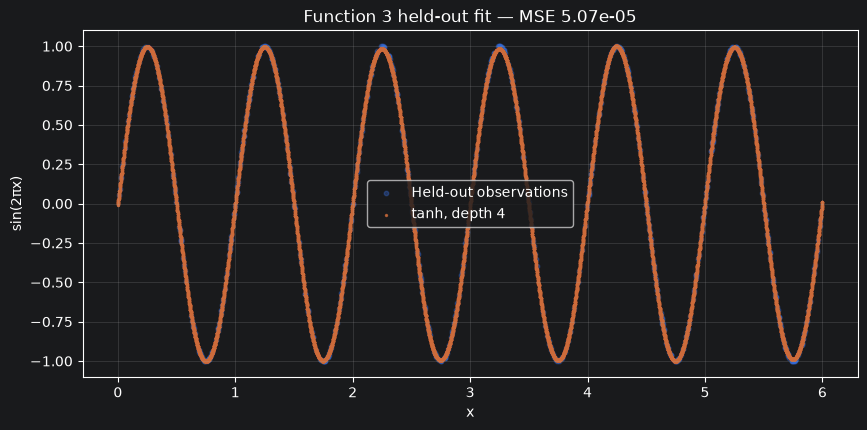

2026-09-06 18:11:07,947 | INFO | going_deeper | Function 3 selected tanh_depth_4; held-out MSE 0.00005072


In [6]:
function_3_frame = pd.read_csv(
    filepath_or_buffer=EXERCISE_DIRECTORY / "function_3.csv",
    dtype={"x": np.float32, "y": np.float32},
)
function_3_features = function_3_frame.loc[:, ["x"]].to_numpy(dtype=np.float32)
function_3_targets = function_3_frame.loc[:, ["y"]].to_numpy(dtype=np.float32)
function_3_partitions = split_regression_data(
    features=function_3_features,
    targets=function_3_targets,
)

search_random_generator = np.random.default_rng(seed=RANDOM_SEED)
search_train_indices = search_random_generator.choice(
    a=function_3_partitions["X_train"].shape[0],
    size=20_000,
    replace=False,
)
function_3_search_partitions = {
    "X_train": function_3_partitions["X_train"][search_train_indices],
    "y_train": function_3_partitions["y_train"][search_train_indices],
    "X_validation": function_3_partitions["X_validation"],
    "y_validation": function_3_partitions["y_validation"],
    "X_test": function_3_partitions["X_test"],
    "y_test": function_3_partitions["y_test"],
}

function_3_results: list[dict[str, Any]] = []
function_3_models: dict[str, keras.Model] = {}
activation_names = ("tanh", "relu", "sigmoid")
depths = (1, 2, 4)

for activation_number, activation_name in enumerate(activation_names):
    for depth in depths:
        configuration_name = f"{activation_name}_depth_{depth}"
        experiment_start = perf_counter()
        configured_model = build_regressor(
            hidden_units=tuple(32 for _ in range(depth)),
            activation=activation_name,
            optimizer=keras.optimizers.Adam(learning_rate=0.003),
            seed=RANDOM_SEED + 200 + activation_number * 10 + depth,
            model_name=configuration_name,
        )
        configured_history, validation_mse = fit_regressor(
            model=configured_model,
            data_partitions=function_3_search_partitions,
            batch_size=512,
            maximum_epochs=120,
            patience=18,
        )
        elapsed_seconds = perf_counter() - experiment_start
        function_3_models[configuration_name] = configured_model
        function_3_results.append(
            {
                "activation": activation_name,
                "depth": depth,
                "configuration": configuration_name,
                "validation_mse": validation_mse,
                "epochs": len(configured_history.history["loss"]),
                "elapsed_seconds": elapsed_seconds,
            }
        )
        LOGGER.info(
            "Function 3 search | %s | val MSE %.8f | epochs %d | %.1fs",
            configuration_name,
            validation_mse,
            len(configured_history.history["loss"]),
            elapsed_seconds,
        )

function_3_results_frame = pd.DataFrame(data=function_3_results).sort_values(
    by="validation_mse"
)
display(function_3_results_frame)
selected_function_3_result = function_3_results_frame.iloc[0].to_dict()
selected_function_3_activation = str(selected_function_3_result["activation"])
selected_function_3_depth = int(selected_function_3_result["depth"])

winner_start = perf_counter()
selected_function_3_model = build_regressor(
    hidden_units=tuple(32 for _ in range(selected_function_3_depth)),
    activation=selected_function_3_activation,
    optimizer=keras.optimizers.Adam(learning_rate=0.002),
    seed=RANDOM_SEED + 333,
    model_name="function_3_winner_full_data",
)
selected_function_3_history, selected_function_3_validation_mse = fit_regressor(
    model=selected_function_3_model,
    data_partitions=function_3_partitions,
    batch_size=512,
    maximum_epochs=180,
    patience=25,
)
winner_elapsed_seconds = perf_counter() - winner_start
function_3_test_mse = float(
    selected_function_3_model.evaluate(
        x=function_3_partitions["X_test"],
        y=function_3_partitions["y_test"],
        batch_size=1024,
        verbose=0,
    )
)
function_3_predictions = selected_function_3_model.predict(
    x=function_3_partitions["X_test"],
    batch_size=1024,
    verbose=0,
).reshape((-1,))
function_3_sort_order = np.argsort(a=function_3_partitions["X_test"][:, 0])

function_3_figure, function_3_axis = plt.subplots(figsize=(10, 4.5))
function_3_axis.scatter(
    x=function_3_partitions["X_test"][::40, 0],
    y=function_3_partitions["y_test"][::40, 0],
    s=10,
    alpha=0.35,
    label="Held-out observations",
)
function_3_axis.scatter(
    x=function_3_partitions["X_test"][function_3_sort_order, 0],
    y=function_3_predictions[function_3_sort_order],
    s=2,
    alpha=0.75,
    label=f"{selected_function_3_activation}, depth {selected_function_3_depth}",
)
function_3_axis.set(
    title=f"Function 3 held-out fit — MSE {function_3_test_mse:.2e}",
    xlabel="x",
    ylabel="sin(2πx)",
)
function_3_axis.grid(visible=True, alpha=0.25)
function_3_axis.legend()
save_figure(figure=function_3_figure, file_name="function_3_fit.png")
plt.show()

METRIC_RECORDS.append(
    {
        "stage": "Function 3",
        "experiment": selected_function_3_result["configuration"],
        "metric": "test_mse",
        "value": function_3_test_mse,
        "threshold": 1e-2,
        "passed": function_3_test_mse <= 1e-2,
    }
)
for experiment_result in function_3_results:
    TIMING_RECORDS.append(
        {
            "stage": "Function 3 search",
            "experiment": experiment_result["configuration"],
            "epochs": experiment_result["epochs"],
            "elapsed_seconds": experiment_result["elapsed_seconds"],
        }
    )
TIMING_RECORDS.append(
    {
        "stage": "Function 3 final",
        "experiment": selected_function_3_result["configuration"],
        "epochs": len(selected_function_3_history.history["loss"]),
        "elapsed_seconds": winner_elapsed_seconds,
    }
)
LOGGER.info(
    "Function 3 selected %s; held-out MSE %.8f",
    selected_function_3_result["configuration"],
    function_3_test_mse,
)

In [7]:
# Preserve the original section-ending report format.
display(
    Markdown(
        f"""```text
loss on test segment: {function_3_test_mse:.12g}
```"""
    )
)

```text
loss on test segment: 5.07232762175e-05
```

In [8]:
def sin_activation(inputs: tf.Tensor) -> tf.Tensor:
    """Apply an elementwise sine activation using the Keras operations API.

    Args:
        inputs: Tensor of pre-activation values.

    Returns:
        Tensor containing the elementwise sine.
    """
    return keras.ops.sin(inputs)

In [9]:
def build_sine_model(*, informed_initialization: bool, seed: int) -> keras.Model:
    """Build the one-neuron sine model.

    Args:
        informed_initialization: Whether to initialize a=2π and b=0.
        seed: Random seed for the default initializer.

    Returns:
        Compiled one-neuron sine model.
    """
    keras.utils.set_random_seed(seed=seed)
    sine_input = keras.Input(shape=(1,), name="x")
    kernel_initializer: keras.initializers.Initializer
    if informed_initialization:
        kernel_initializer = keras.initializers.Constant(value=2.0 * np.pi)
    else:
        kernel_initializer = keras.initializers.GlorotUniform(seed=seed)
    sine_output = keras.layers.Dense(
        units=1,
        activation=sin_activation,
        kernel_initializer=kernel_initializer,
        bias_initializer=keras.initializers.Zeros(),
        name="sine_neuron",
    )(sine_input)
    sine_model = keras.Model(
        inputs=sine_input,
        outputs=sine_output,
        name="single_sine_neuron",
    )
    sine_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="mse",
    )
    return sine_model


sine_model_results: list[dict[str, Any]] = []
sine_models: dict[str, keras.Model] = {}
for initialization_number, initialization_name in enumerate(("default", "informed")):
    configured_sine_model = build_sine_model(
        informed_initialization=initialization_name == "informed",
        seed=RANDOM_SEED + 400 + initialization_number,
    )
    sine_start = perf_counter()
    sine_history, sine_validation_mse = fit_regressor(
        model=configured_sine_model,
        data_partitions=function_3_partitions,
        batch_size=512,
        maximum_epochs=100,
        patience=15,
    )
    sine_elapsed_seconds = perf_counter() - sine_start
    sine_test_mse = float(
        configured_sine_model.evaluate(
            x=function_3_partitions["X_test"],
            y=function_3_partitions["y_test"],
            batch_size=1024,
            verbose=0,
        )
    )
    sine_parameters = configured_sine_model.get_layer(
        name="sine_neuron"
    ).get_weights()
    sine_models[initialization_name] = configured_sine_model
    sine_model_results.append(
        {
            "initialization": initialization_name,
            "validation_mse": sine_validation_mse,
            "test_mse": sine_test_mse,
            "learned_a": float(sine_parameters[0][0, 0]),
            "learned_b": float(sine_parameters[1][0]),
            "epochs": len(sine_history.history["loss"]),
            "elapsed_seconds": sine_elapsed_seconds,
        }
    )
    TIMING_RECORDS.append(
        {
            "stage": "Sine neuron",
            "experiment": initialization_name,
            "epochs": len(sine_history.history["loss"]),
            "elapsed_seconds": sine_elapsed_seconds,
        }
    )

sine_results_frame = pd.DataFrame(data=sine_model_results)
display(sine_results_frame)
informed_sine_result = next(
    result
    for result in sine_model_results
    if result["initialization"] == "informed"
)
METRIC_RECORDS.append(
    {
        "stage": "Sine neuron",
        "experiment": "informed initialization",
        "metric": "test_mse",
        "value": informed_sine_result["test_mse"],
        "threshold": 1e-4,
        "passed": informed_sine_result["test_mse"] <= 1e-4,
    }
)
LOGGER.info(
    "Informed sine held-out MSE %.10f; learned a %.6f, b %.6f",
    informed_sine_result["test_mse"],
    informed_sine_result["learned_a"],
    informed_sine_result["learned_b"],
)

,initialization,validation_mse,test_mse,learned_a,learned_b,epochs,elapsed_seconds
0,default,4.894595e-01,4.882393e-01,-0.057772,0.168144,17,3.981201
1,informed,8.804146e-13,6.897751e-10,6.283178,-0.000014,16,3.872352


2026-09-06 18:11:16,169 | INFO | going_deeper | Informed sine held-out MSE 0.0000000007; learned a 6.283178, b -0.000014


In [10]:
# Preserve the original section-ending report format.
display(
    Markdown(
        f"""```text
loss on test segment: {informed_sine_result['test_mse']:.12g}
```"""
    )
)

```text
loss on test segment: 6.89775125906e-10
```

Let's explore the sinus activation. For this we will simplify the settings. We will generate 3 samples, with
$x = [0, 0.5, 1]$  and  $y=[sin(0), sin(0.5), sin(1)]$. We will keep using the simplest neural network, that has one input and one output, with no hidden layers. Hence the possible functions that the network can give us are functions of the form
$y=sin(a\cdot x+b)$.

We can use the simple setting to compute and visualize the loss surface. As you recall, the loss is given by
$\sum_i{(sin(a\cdot x_i+b)-y_i)^2}$

Create a matrix so that in the (i,j) entry there will be the loss for  $a = \frac{2\pi}{600}\cdot i$ and $b= \frac{2\pi}{600}\cdot j$. Visualize this matrix using plt.imshow.

---

### Loss surface for the sine activation

For three fixed samples (x=[0,0.5,1]), visualize the summed squared error of (sin(ax+b)) against the corrected target (sin(2pi x)). Both (a) and (b) span ([0,2pi]) on a 600×600 vectorized grid.

2026-09-06 18:11:16,531 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\sine_loss_surface.png


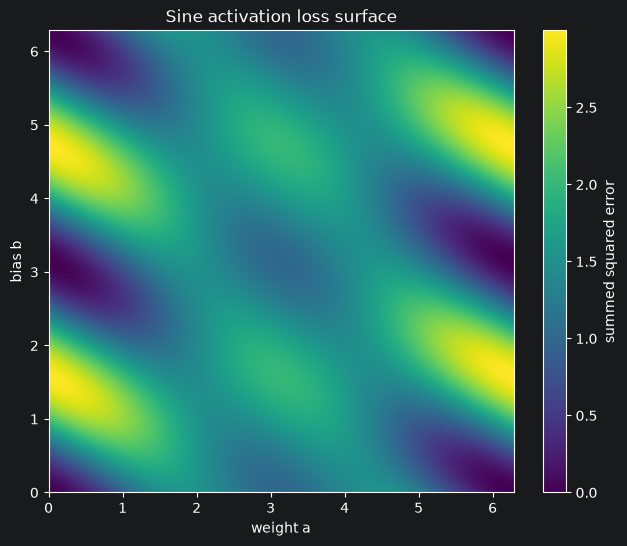

In [11]:
surface_samples = np.asarray([0.0, 0.5, 1.0], dtype=np.float32)
surface_targets = np.sin(2.0 * np.pi * surface_samples)
surface_axis_values = np.linspace(
    start=0.0,
    stop=2.0 * np.pi,
    num=600,
    dtype=np.float32,
)
surface_a_grid, surface_b_grid = np.meshgrid(
    surface_axis_values,
    surface_axis_values,
    indexing="xy",
)
sine_surface_predictions = np.sin(
    surface_a_grid[:, :, None] * surface_samples[None, None, :]
    + surface_b_grid[:, :, None]
)
sine_loss_surface = np.sum(
    a=np.square(sine_surface_predictions - surface_targets[None, None, :]),
    axis=2,
)

sine_surface_figure, sine_surface_axis = plt.subplots(figsize=(7.5, 6))
sine_surface_image = sine_surface_axis.imshow(
    X=sine_loss_surface,
    origin="lower",
    extent=(0.0, 2.0 * np.pi, 0.0, 2.0 * np.pi),
    aspect="auto",
    cmap="viridis",
)
sine_surface_axis.set(
    title="Sine activation loss surface",
    xlabel="weight a",
    ylabel="bias b",
)
sine_surface_figure.colorbar(
    mappable=sine_surface_image,
    ax=sine_surface_axis,
    label="summed squared error",
)
save_figure(figure=sine_surface_figure, file_name="sine_loss_surface.png")
plt.show()

assert sine_loss_surface.shape == (600, 600)
assert np.isfinite(sine_loss_surface).all()

Do the same for the beloved activation, tanh. Based on the images, what makes sinus a poor activation function and tanh a good activation function? answer in  $\underline{a\ cell\ below}$.

---

### Tanh comparison

Repeat the same calculation for $\tanh(ax+b)$. The contrast illustrates why a bounded monotonic activation is easier to optimize than a periodic activation: tanh produces a comparatively coherent basin, whereas sine repeatedly maps distant parameter values to similar outputs and creates many competing basins.

2026-09-06 18:11:17,101 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\tanh_loss_surface.png


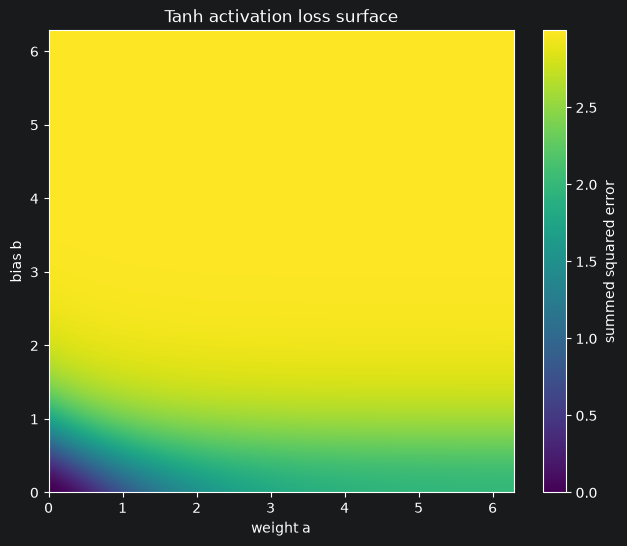

**Interpretation.** Sine is periodic, so many widely separated ((a,b)) pairs produce similar predictions. Its derivatives also alternate sign, creating repeated valleys, ridges, and stationary regions. Gradient descent therefore depends strongly on initialization. Tanh is monotonic and has one central transition, so its useful parameter region is organized into a more continuous basin. Tanh can still saturate for large magnitudes, but it avoids the repeated equivalent optima caused by periodicity.

In [12]:
tanh_surface_predictions = np.tanh(
    surface_a_grid[:, :, None] * surface_samples[None, None, :]
    + surface_b_grid[:, :, None]
)
tanh_loss_surface = np.sum(
    a=np.square(tanh_surface_predictions - surface_targets[None, None, :]),
    axis=2,
)

tanh_surface_figure, tanh_surface_axis = plt.subplots(figsize=(7.5, 6))
tanh_surface_image = tanh_surface_axis.imshow(
    X=tanh_loss_surface,
    origin="lower",
    extent=(0.0, 2.0 * np.pi, 0.0, 2.0 * np.pi),
    aspect="auto",
    cmap="viridis",
)
tanh_surface_axis.set(
    title="Tanh activation loss surface",
    xlabel="weight a",
    ylabel="bias b",
)
tanh_surface_figure.colorbar(
    mappable=tanh_surface_image,
    ax=tanh_surface_axis,
    label="summed squared error",
)
save_figure(figure=tanh_surface_figure, file_name="tanh_loss_surface.png")
plt.show()

display(
    Markdown(
        "**Interpretation.** Sine is periodic, so many widely separated ((a,b)) "
        "pairs produce similar predictions. Its derivatives also alternate sign, "
        "creating repeated valleys, ridges, and stationary regions. Gradient descent "
        "therefore depends strongly on initialization. Tanh is monotonic and has one "
        "central transition, so its useful parameter region is organized into a more "
        "continuous basin. Tanh can still saturate for large magnitudes, but it avoids "
        "the repeated equivalent optima caused by periodicity."
    )
)

### Bonus:
When training neural networks using keras we can use callback functions: There are functions that are called automatically during the training and can be of several usages. For example, we can use a callback function to save our model to a file upon the ending of an epoch.
Below you will find a custom callback that keeps the weights for a and b in your sinus model. Use it like this:

```python
wh = WeightsHistory()
model.fit(X_train, Y_train, batch_size = 100, epochs = 10, verbose=2, callbacks=[wh])
```

After you try training your model using the sinus activation you can plot the path your model took on the a-b plane. Add to your loss surface visualization a plot showing the a-b values during training.

Note: after using plt.imshow you got an image of the size $600\times 600$. You will have to scale your a-b path accordingly to see it on the same graph. Try zooming (by changing the scale of the image, enlarging the size of your image or using any other mean) to get a better view of the a-b path. Can you explain why didn't you get a convergence?

---

### Bonus: trace optimization across the sine loss surface

A modern Keras callback records the sine neuron's weight and bias at each epoch. The trajectory is overlaid directly in parameter coordinates because the image uses the physical extent ([0,2pi]) on both axes.

In [13]:
class WeightsHistory(keras.callbacks.Callback):
    """Record a one-neuron layer's weight and bias after every epoch."""

    def __init__(self, *, layer_name: str = "sine_neuron") -> None:
        """Initialize the history callback.

        Args:
            layer_name: Name of the layer whose parameters should be recorded.
        """
        super().__init__()
        self.layer_name = layer_name
        self.weights: list[float] = []
        self.biases: list[float] = []

    def on_epoch_end(
        self,
        epoch: int,
        logs: dict[str, float] | None = None,
    ) -> None:
        """Capture parameters at the end of an epoch.

        Args:
            epoch: Zero-based epoch number supplied by Keras.
            logs: Keras metric mapping for the epoch.
        """
        del epoch, logs
        if self.model is None:
            raise RuntimeError("The callback is not attached to a model")
        layer_parameters = self.model.get_layer(name=self.layer_name).get_weights()
        if len(layer_parameters) != 2:
            raise ValueError("Expected exactly one kernel and one bias array")
        self.weights.append(float(layer_parameters[0][0, 0]))
        self.biases.append(float(layer_parameters[1][0]))

2026-09-06 18:11:35,089 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\sine_optimization_trajectory.png


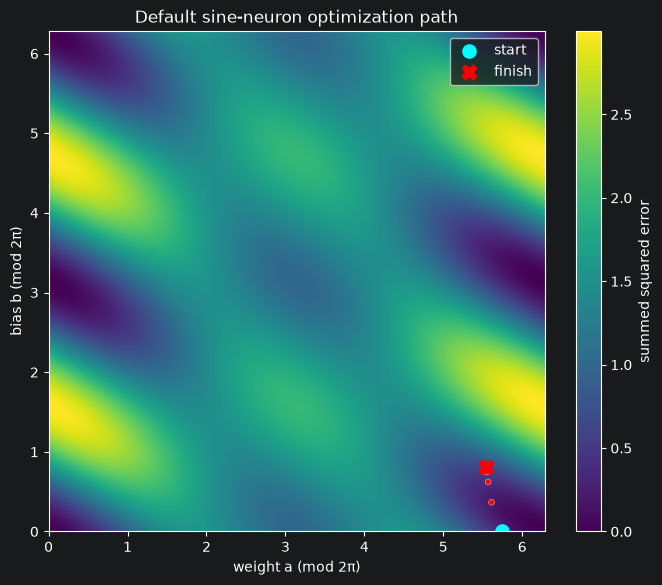

**Why convergence can fail.** The trajectory follows only local slope. Because sine repeats, the loss surface has many basins and flat or opposing directions; a random start can enter a basin representing the wrong frequency or phase. The informed (a=2pi, b=0) initialization begins in the correct basin and avoids this ambiguity.

In [14]:
trajectory_model = build_sine_model(
    informed_initialization=False,
    seed=RANDOM_SEED + 500,
)
trajectory_history = WeightsHistory(layer_name="sine_neuron")
trajectory_start_parameters = trajectory_model.get_layer(
    name="sine_neuron"
).get_weights()
trajectory_history.weights.append(float(trajectory_start_parameters[0][0, 0]))
trajectory_history.biases.append(float(trajectory_start_parameters[1][0]))
trajectory_start = perf_counter()
trajectory_model.fit(
    x=function_3_search_partitions["X_train"],
    y=function_3_search_partitions["y_train"],
    validation_data=(
        function_3_partitions["X_validation"],
        function_3_partitions["y_validation"],
    ),
    batch_size=512,
    epochs=80,
    callbacks=[trajectory_history],
    verbose=0,
    shuffle=True,
)
trajectory_elapsed_seconds = perf_counter() - trajectory_start
TIMING_RECORDS.append(
    {
        "stage": "Sine neuron",
        "experiment": "trajectory",
        "epochs": 80,
        "elapsed_seconds": trajectory_elapsed_seconds,
    }
)

trajectory_weights = np.mod(
    np.asarray(trajectory_history.weights, dtype=np.float32),
    2.0 * np.pi,
)
trajectory_biases = np.mod(
    np.asarray(trajectory_history.biases, dtype=np.float32),
    2.0 * np.pi,
)
trajectory_figure, trajectory_axis = plt.subplots(figsize=(8, 6.5))
trajectory_image = trajectory_axis.imshow(
    X=sine_loss_surface,
    origin="lower",
    extent=(0.0, 2.0 * np.pi, 0.0, 2.0 * np.pi),
    aspect="auto",
    cmap="viridis",
)
trajectory_axis.scatter(
    x=trajectory_weights,
    y=trajectory_biases,
    c=np.arange(trajectory_weights.size),
    cmap="autumn",
    s=18,
    edgecolors="white",
    linewidths=0.25,
)
trajectory_axis.scatter(
    x=trajectory_weights[:1],
    y=trajectory_biases[:1],
    s=90,
    marker="o",
    color="cyan",
    label="start",
)
trajectory_axis.scatter(
    x=trajectory_weights[-1:],
    y=trajectory_biases[-1:],
    s=110,
    marker="X",
    color="red",
    label="finish",
)
trajectory_axis.set(
    title="Default sine-neuron optimization path",
    xlabel="weight a (mod 2π)",
    ylabel="bias b (mod 2π)",
)
trajectory_axis.legend()
trajectory_figure.colorbar(
    mappable=trajectory_image,
    ax=trajectory_axis,
    label="summed squared error",
)
save_figure(
    figure=trajectory_figure,
    file_name="sine_optimization_trajectory.png",
)
plt.show()

display(
    Markdown(
        "**Why convergence can fail.** The trajectory follows only local slope. "
        "Because sine repeats, the loss surface has many basins and flat or opposing "
        "directions; a random start can enter a basin representing the wrong frequency "
        "or phase. The informed (a=2pi, b=0) initialization begins in the correct "
        "basin and avoids this ambiguity."
    )
)

## Stage 2- predict digits from MNIST
Use your knowledge to create a good prediction for the MNIST dataset. Note that this a classification problem, and you will have to use a different loss: for example, the binary cross entropy (log loss). Furthermore, you might want to use softmax to generate predictions. You can use activation='softmax' in the last layer of your network.
good luck!

---

## Stage 2 — classify MNIST digits

Use the canonical 60,000-image training set and 10,000-image test set. Normalize pixels to float32 in [0, 1], then make a stratified 54,000/6,000 train/validation split. The network has 784 inputs, 128 ReLU units, 64 ReLU units, and 10 softmax outputs. It is trained with Adam and sparse categorical cross-entropy. Final reporting includes test loss, accuracy, balanced accuracy, macro one-vs-rest AUC, and a confusion matrix.

Balanced accuracy is the unweighted mean recall across the ten digits, so each digit contributes equally even when class counts differ. The original loss suggestion is retained above; this implementation uses sparse categorical cross-entropy for mutually exclusive integer digit labels.

In [15]:
from sklearn.model_selection import StratifiedShuffleSplit

(mnist_train_images_raw, mnist_train_labels), (
    mnist_test_images_raw,
    mnist_test_labels,
) = keras.datasets.mnist.load_data(path="mnist.npz")

mnist_train_images_all = (
    mnist_train_images_raw.reshape((-1, 28 * 28)).astype(np.float32) / 255.0
)
mnist_test_images = (
    mnist_test_images_raw.reshape((-1, 28 * 28)).astype(np.float32) / 255.0
)
mnist_train_labels_all = mnist_train_labels.astype(np.int64)
mnist_test_labels = mnist_test_labels.astype(np.int64)

mnist_splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=6_000,
    random_state=RANDOM_SEED,
)
mnist_train_indices, mnist_validation_indices = next(
    mnist_splitter.split(
        X=mnist_train_images_all,
        y=mnist_train_labels_all,
    )
)
mnist_train_images = mnist_train_images_all[mnist_train_indices]
mnist_train_labels = mnist_train_labels_all[mnist_train_indices]
mnist_validation_images = mnist_train_images_all[mnist_validation_indices]
mnist_validation_labels = mnist_train_labels_all[mnist_validation_indices]

assert mnist_train_images.shape == (54_000, 784)
assert mnist_validation_images.shape == (6_000, 784)
assert mnist_test_images.shape == (10_000, 784)
assert mnist_train_images.dtype == np.float32
LOGGER.info(
    "MNIST shapes | train %s | validation %s | test %s",
    mnist_train_images.shape,
    mnist_validation_images.shape,
    mnist_test_images.shape,
)

2026-09-06 18:11:35,898 | INFO | going_deeper | MNIST shapes | train (54000, 784) | validation (6000, 784) | test (10000, 784)


In [16]:
from sklearn.metrics import balanced_accuracy_score

keras.utils.set_random_seed(seed=RANDOM_SEED + 600)
mnist_input = keras.Input(shape=(784,), name="pixels")
mnist_hidden_1 = keras.layers.Dense(
    units=128,
    activation="relu",
    kernel_initializer=keras.initializers.HeNormal(seed=RANDOM_SEED + 601),
    name="hidden_128",
)(mnist_input)
mnist_hidden_2 = keras.layers.Dense(
    units=64,
    activation="relu",
    kernel_initializer=keras.initializers.HeNormal(seed=RANDOM_SEED + 602),
    name="hidden_64",
)(mnist_hidden_1)
mnist_output = keras.layers.Dense(
    units=10,
    activation="softmax",
    kernel_initializer=keras.initializers.GlorotUniform(seed=RANDOM_SEED + 603),
    name="digit_probabilities",
)(mnist_hidden_2)
mnist_model = keras.Model(
    inputs=mnist_input,
    outputs=mnist_output,
    name="mnist_dense_classifier",
)
mnist_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
mnist_model.summary(print_fn=LOGGER.info)

mnist_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    min_delta=1e-4,
    restore_best_weights=True,
)
mnist_start = perf_counter()
mnist_history = mnist_model.fit(
    x=mnist_train_images,
    y=mnist_train_labels,
    validation_data=(mnist_validation_images, mnist_validation_labels),
    batch_size=256,
    epochs=20,
    callbacks=[mnist_early_stopping],
    verbose=0,
    shuffle=True,
)
mnist_elapsed_seconds = perf_counter() - mnist_start


2026-09-06 18:11:35,987 | INFO | going_deeper | Model: "mnist_dense_classifier"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_128 (Dense)              │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_64 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit_probabilities (Dense)     │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 109,386 (427.29 KB)
 Trainable params: 109,386 (427.29 KB)

2026-09-06 18:11:53,929 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\mnist_confusion_matrix.png


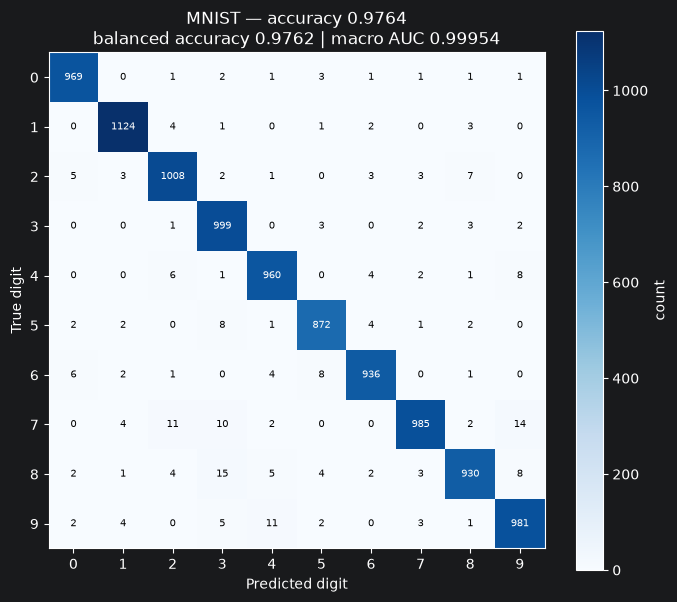

2026-09-06 18:11:54,213 | INFO | going_deeper | MNIST | test loss 0.081997 | accuracy 0.97640 | balanced accuracy 0.97624 | macro OvR AUC 0.999536 | epochs 14 | 17.1s


In [17]:
from sklearn.metrics import balanced_accuracy_score

mnist_test_loss, mnist_test_accuracy = mnist_model.evaluate(
    x=mnist_test_images,
    y=mnist_test_labels,
    batch_size=512,
    verbose=0,
)
mnist_test_probabilities = mnist_model.predict(
    x=mnist_test_images,
    batch_size=512,
    verbose=0,
)
mnist_test_predictions = np.argmax(
    a=mnist_test_probabilities,
    axis=1,
)
mnist_test_balanced_accuracy = float(
    balanced_accuracy_score(
        y_true=mnist_test_labels,
        y_pred=mnist_test_predictions,
    )
)
mnist_macro_auc = float(
    roc_auc_score(
        y_true=mnist_test_labels,
        y_score=mnist_test_probabilities,
        multi_class="ovr",
        average="macro",
    )
)
mnist_confusion_matrix = confusion_matrix(
    y_true=mnist_test_labels,
    y_pred=mnist_test_predictions,
    labels=np.arange(10),
)

# Verify balanced accuracy independently from the ten per-digit recalls.
mnist_per_digit_recall = np.diag(v=mnist_confusion_matrix) / np.sum(
    a=mnist_confusion_matrix, axis=1
)
np.testing.assert_allclose(
    actual=mnist_test_balanced_accuracy,
    desired=np.mean(a=mnist_per_digit_recall),
    rtol=1e-12,
)
assert 0.0 <= mnist_test_balanced_accuracy <= 1.0

mnist_figure, mnist_axis = plt.subplots(figsize=(8, 7))
mnist_image = mnist_axis.imshow(
    X=mnist_confusion_matrix,
    cmap="Blues",
)
mnist_axis.set(
    title=(
        f"MNIST — accuracy {float(mnist_test_accuracy):.4f}\n"
        f"balanced accuracy {mnist_test_balanced_accuracy:.4f} | "
        f"macro AUC {mnist_macro_auc:.5f}"
    ),
    xlabel="Predicted digit",
    ylabel="True digit",
    xticks=np.arange(10),
    yticks=np.arange(10),
)
for true_digit in range(10):
    for predicted_digit in range(10):
        mnist_axis.text(
            x=predicted_digit,
            y=true_digit,
            s=str(mnist_confusion_matrix[true_digit, predicted_digit]),
            ha="center",
            va="center",
            fontsize=7,
            color=(
                "white"
                if mnist_confusion_matrix[true_digit, predicted_digit]
                > mnist_confusion_matrix.max() * 0.55
                else "black"
            ),
        )
mnist_figure.colorbar(
    mappable=mnist_image,
    ax=mnist_axis,
    label="count",
)
save_figure(figure=mnist_figure, file_name="mnist_confusion_matrix.png")
plt.show()

# Replace this stage's records when re-running the reporting cell.
METRIC_RECORDS[:] = [
    record for record in METRIC_RECORDS if record["stage"] != "MNIST"
]
METRIC_RECORDS.extend(
    [
        {
            "stage": "MNIST",
            "experiment": "dense_128_64",
            "metric": "test_loss",
            "value": float(mnist_test_loss),
            "threshold": None,
            "passed": True,
        },
        {
            "stage": "MNIST",
            "experiment": "dense_128_64",
            "metric": "test_accuracy",
            "value": float(mnist_test_accuracy),
            "threshold": 0.97,
            "passed": float(mnist_test_accuracy) >= 0.97,
        },
        {
            "stage": "MNIST",
            "experiment": "dense_128_64",
            "metric": "test_balanced_accuracy",
            "value": mnist_test_balanced_accuracy,
            "threshold": None,
            "passed": bool(np.isfinite(mnist_test_balanced_accuracy)),
        },
        {
            "stage": "MNIST",
            "experiment": "dense_128_64",
            "metric": "macro_ovr_auc",
            "value": mnist_macro_auc,
            "threshold": 0.995,
            "passed": mnist_macro_auc >= 0.995,
        },
    ]
)
TIMING_RECORDS[:] = [
    record for record in TIMING_RECORDS if record["stage"] != "MNIST"
]
TIMING_RECORDS.append(
    {
        "stage": "MNIST",
        "experiment": "dense_128_64",
        "epochs": len(mnist_history.history["loss"]),
        "elapsed_seconds": mnist_elapsed_seconds,
    }
)
LOGGER.info(
    "MNIST | test loss %.6f | accuracy %.5f | balanced accuracy %.5f | macro OvR AUC %.6f | epochs %d | %.1fs",
    float(mnist_test_loss),
    float(mnist_test_accuracy),
    mnist_test_balanced_accuracy,
    mnist_macro_auc,
    len(mnist_history.history["loss"]),
    mnist_elapsed_seconds,
)

In [18]:
# Preserve the original solution's section-ending line. Historically, this
# value was accuracy even though the label said "loss"; the clarification keeps
# the original output recognizable without obscuring its meaning.
display(
    Markdown(
        f"""```text
loss on test segment: {float(mnist_test_accuracy):.12g}
```

_Original label retained; this value is test accuracy._"""
    )
)

```text
loss on test segment: 0.976400017738
```

_Original label retained; this value is test accuracy._

## Stage 3 - exploring deep neural networks
In this part we will explore the problems with training deep networks.

---

## Stage 3 — depth, sigmoid saturation, and vanishing gradients

Approximate the identity function on 10,000 seeded samples. Compare a shallow three-unit sigmoid network with a network containing exactly 50 three-unit sigmoid hidden layers, then compute every kernel gradient using `tf.GradientTape`.

We will work with the simplest data possible and will try to approximate the identity function, with one feature.
Generate 10,000 samples using np.random.random and have  $y=x$. Create a neural network with a single hidden layer with 3 neurons in it and sigmoid activation. Approximate the identity function.

---

### Shallow identity network

Generate $x\sim U(0,1)$ and set (y=x). Fit one hidden sigmoid layer with three units and a linear output.

2026-09-06 18:12:29,369 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\identity_shallow_fit.png


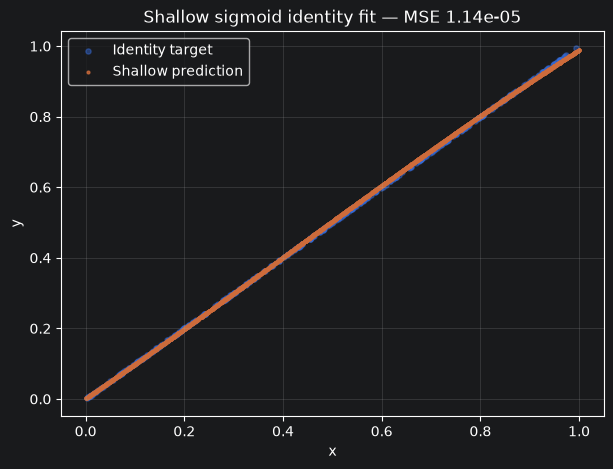

2026-09-06 18:12:29,455 | INFO | going_deeper | Shallow identity | test MSE 0.00001143 | epochs 250 | 34.7s


In [19]:
identity_random_generator = np.random.default_rng(seed=RANDOM_SEED)
identity_features = identity_random_generator.random(
    size=(10_000, 1),
    dtype=np.float32,
)
identity_targets = identity_features.copy()
identity_partitions = split_regression_data(
    features=identity_features,
    targets=identity_targets,
)

shallow_identity_model = build_regressor(
    hidden_units=(3,),
    activation="sigmoid",
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    seed=RANDOM_SEED + 700,
    model_name="shallow_identity",
)
shallow_start = perf_counter()
shallow_history, shallow_validation_mse = fit_regressor(
    model=shallow_identity_model,
    data_partitions=identity_partitions,
    batch_size=256,
    maximum_epochs=250,
    patience=25,
)
shallow_elapsed_seconds = perf_counter() - shallow_start
shallow_test_mse = float(
    shallow_identity_model.evaluate(
        x=identity_partitions["X_test"],
        y=identity_partitions["y_test"],
        batch_size=512,
        verbose=0,
    )
)
shallow_predictions = shallow_identity_model.predict(
    x=identity_partitions["X_test"],
    batch_size=512,
    verbose=0,
).reshape((-1,))
identity_sort_order = np.argsort(a=identity_partitions["X_test"][:, 0])

shallow_figure, shallow_axis = plt.subplots(figsize=(7, 5))
shallow_axis.scatter(
    x=identity_partitions["X_test"][::10, 0],
    y=identity_partitions["y_test"][::10, 0],
    s=14,
    alpha=0.45,
    label="Identity target",
)
shallow_axis.scatter(
    x=identity_partitions["X_test"][identity_sort_order, 0],
    y=shallow_predictions[identity_sort_order],
    s=4,
    alpha=0.8,
    label="Shallow prediction",
)
shallow_axis.set(
    title=f"Shallow sigmoid identity fit — MSE {shallow_test_mse:.2e}",
    xlabel="x",
    ylabel="y",
)
shallow_axis.grid(visible=True, alpha=0.25)
shallow_axis.legend()
save_figure(figure=shallow_figure, file_name="identity_shallow_fit.png")
plt.show()

METRIC_RECORDS.append(
    {
        "stage": "Identity",
        "experiment": "1 hidden layer × 3 sigmoid",
        "metric": "test_mse",
        "value": shallow_test_mse,
        "threshold": 1e-3,
        "passed": shallow_test_mse <= 1e-3,
    }
)
TIMING_RECORDS.append(
    {
        "stage": "Identity",
        "experiment": "shallow",
        "epochs": len(shallow_history.history["loss"]),
        "elapsed_seconds": shallow_elapsed_seconds,
    }
)
LOGGER.info(
    "Shallow identity | test MSE %.8f | epochs %d | %.1fs",
    shallow_test_mse,
    len(shallow_history.history["loss"]),
    shallow_elapsed_seconds,
)

In [20]:
# Preserve the original section-ending report format.
display(
    Markdown(
        f"""```text
loss on test segment: {shallow_test_mse:.12g}
```"""
    )
)

```text
loss on test segment: 1.14314752864e-05
```

Add 50 hidden layers to your network, again, with 3 neurons in each layer and sigmoid activatoin. Try approximating the identity function using this network.

---

### Fifty-layer sigmoid identity network

Keep the width at three units but stack exactly 50 sigmoid hidden layers. The repeated sigmoid derivatives attenuate the back-propagated signal, making the early layers extremely difficult to train.

2026-09-06 18:12:54,366 | WARNING | tensorflow | 5 out of the last 27 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000019A0CD7F380> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2026-09-06 18:12:54,919 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\identity_deep_fit.png


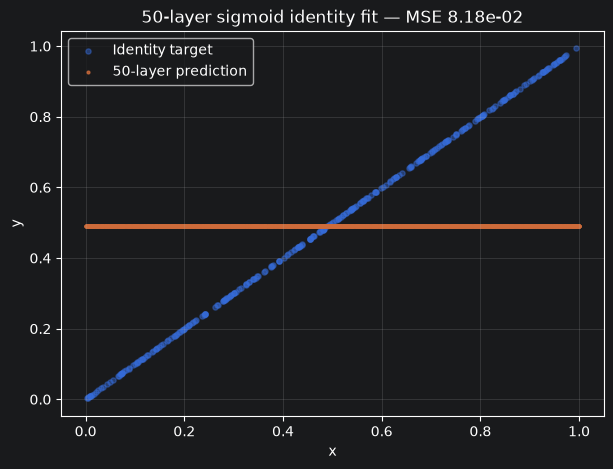

2026-09-06 18:12:55,074 | INFO | going_deeper | Deep identity | test MSE 0.08184118 | shallow/deep ratio 7159.28 | epochs 80 | 23.5s


In [21]:
deep_identity_model = build_regressor(
    hidden_units=tuple(3 for _ in range(50)),
    activation="sigmoid",
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    seed=RANDOM_SEED + 800,
    model_name="deep_identity_50_layers",
)
assert sum(
    isinstance(layer, keras.layers.Dense) and layer.name.startswith("hidden_")
    for layer in deep_identity_model.layers
) == 50

deep_start = perf_counter()
deep_history, deep_validation_mse = fit_regressor(
    model=deep_identity_model,
    data_partitions=identity_partitions,
    batch_size=256,
    maximum_epochs=80,
    patience=12,
)
deep_elapsed_seconds = perf_counter() - deep_start
deep_test_mse = float(
    deep_identity_model.evaluate(
        x=identity_partitions["X_test"],
        y=identity_partitions["y_test"],
        batch_size=512,
        verbose=0,
    )
)
deep_predictions = deep_identity_model.predict(
    x=identity_partitions["X_test"],
    batch_size=512,
    verbose=0,
).reshape((-1,))

deep_figure, deep_axis = plt.subplots(figsize=(7, 5))
deep_axis.scatter(
    x=identity_partitions["X_test"][::10, 0],
    y=identity_partitions["y_test"][::10, 0],
    s=14,
    alpha=0.45,
    label="Identity target",
)
deep_axis.scatter(
    x=identity_partitions["X_test"][identity_sort_order, 0],
    y=deep_predictions[identity_sort_order],
    s=4,
    alpha=0.8,
    label="50-layer prediction",
)
deep_axis.set(
    title=f"50-layer sigmoid identity fit — MSE {deep_test_mse:.2e}",
    xlabel="x",
    ylabel="y",
)
deep_axis.grid(visible=True, alpha=0.25)
deep_axis.legend()
save_figure(figure=deep_figure, file_name="identity_deep_fit.png")
plt.show()

METRIC_RECORDS.append(
    {
        "stage": "Identity",
        "experiment": "50 hidden layers × 3 sigmoid",
        "metric": "test_mse",
        "value": deep_test_mse,
        "threshold": shallow_test_mse,
        "passed": deep_test_mse > shallow_test_mse,
    }
)
TIMING_RECORDS.append(
    {
        "stage": "Identity",
        "experiment": "deep_50",
        "epochs": len(deep_history.history["loss"]),
        "elapsed_seconds": deep_elapsed_seconds,
    }
)
LOGGER.info(
    "Deep identity | test MSE %.8f | shallow/deep ratio %.2f | epochs %d | %.1fs",
    deep_test_mse,
    deep_test_mse / shallow_test_mse,
    len(deep_history.history["loss"]),
    deep_elapsed_seconds,
)

In [22]:
# Preserve the original section-ending report format.
display(
    Markdown(
        f"""```text
loss on test segment: {deep_test_mse:.12g}
```"""
    )
)

```text
loss on test segment: 0.0818411782384
```

Why isn't it working? Explain it in  $\underline{a\ cell\ below}$. In your explanation regard the process of back propagation and the formula of gradients found in the first layers of the network. Regard also the possible values of the derivative of the sigmoid function.

---

### Why the 50-layer network fails

**The main problem is vanishing gradients.** Each hidden layer multiplies the backward signal by its activation derivative and the next layer's weights. Across 50 sigmoid layers, the signal reaching the first layers can become extremely small.

For column-vector activations, write $z_l = W_l h_{l-1} + b_l$ and $h_l = \sigma(z_l)$. If $\delta_l = \partial L / \partial z_l$, backpropagation gives

$$
\delta_l = \left(W_{l+1}^{\mathsf{T}}\delta_{l+1}\right)
\odot \sigma'(z_l),
\qquad
\frac{\partial L}{\partial W_l} = \delta_l h_{l-1}^{\mathsf{T}}.
$$

Here, $\odot$ means elementwise multiplication. Repeatedly applying this recurrence carries a product of weight matrices and sigmoid derivatives back toward the input.

**Sigmoid shrinks the signal.** Its derivative satisfies

$$
\sigma'(z) = \sigma(z)\left(1-\sigma(z)\right),
\qquad
0 < \sigma'(z) \leq \frac{1}{4}.
$$

Ignoring the weight matrices just to illustrate the scale, 50 maximum sigmoid-derivative factors give

$$
\left(\frac{1}{4}\right)^{50} \approx 7.9 \times 10^{-31}.
$$

This is an illustration, not a bound on the full gradient: the weight matrices also affect its size. Saturated sigmoid units have derivatives even closer to zero.

**What this means for the fit.** The early layers receive tiny parameter updates and learn little about the input. Later layers can still adjust, so the model may settle on an almost constant prediction instead of the identity function $y=x$. The measured layer-by-layer gradients below test this explanation directly.

In [23]:
display(
    Markdown(
        f"The shallow network reaches test MSE **{shallow_test_mse:.3e}**, "
        f"while the 50-layer sigmoid network reaches **{deep_test_mse:.3e}**. "
        "The much weaker early-layer gradient measured below connects the observed "
        "optimization failure to the chain-rule product described above."
    )
)

The shallow network reaches test MSE **1.143e-05**, while the 50-layer sigmoid network reaches **8.184e-02**. The much weaker early-layer gradient measured below connects the observed optimization failure to the chain-rule product described above.

Run the cell below. In weight_grads you will have a list of the gradients computed in every layer. For each layer take the maximum absolute value of the gradients. Plot a graph of the maximum values against the number of layer. Also plot it in logarithmic scale. Use it to justify your answer from before in  $\underline{a\ cell\ below}$.

---

### Direct gradient measurement

Use `tf.GradientTape` on a fixed held-out batch, take the maximum absolute kernel gradient for each of the 50 hidden layers plus the output layer, and plot the 51 values on linear and logarithmic scales.

In [24]:
def get_kernel_gradients(
    *,
    model: keras.Model,
    inputs: np.ndarray,
    targets: np.ndarray,
) -> list[np.ndarray]:
    """Compute loss gradients for every Dense kernel with GradientTape.

    Args:
        model: Trained regression model.
        inputs: Input batch.
        targets: Target batch.

    Returns:
        Kernel-gradient arrays in forward layer order.
    """
    input_tensor = tf.convert_to_tensor(
        value=inputs,
        dtype=tf.float32,
    )
    target_tensor = tf.convert_to_tensor(
        value=targets,
        dtype=tf.float32,
    )
    kernel_variables = [
        layer.kernel
        for layer in model.layers
        if isinstance(layer, keras.layers.Dense)
    ]
    with tf.GradientTape() as gradient_tape:
        predictions = model(inputs=input_tensor, training=False)
        mean_squared_error = tf.reduce_mean(
            input_tensor=tf.square(x=predictions - target_tensor)
        )
    gradients = gradient_tape.gradient(
        target=mean_squared_error,
        sources=kernel_variables,
    )
    if any(gradient is None for gradient in gradients):
        raise RuntimeError("At least one Dense kernel gradient is disconnected")
    return [gradient.numpy() for gradient in gradients]


# Focused basic-use test on the shallow model: hidden kernel + output kernel.
shallow_kernel_gradients = get_kernel_gradients(
    model=shallow_identity_model,
    inputs=identity_partitions["X_test"][:64],
    targets=identity_partitions["y_test"][:64],
)
assert len(shallow_kernel_gradients) == 2

deep_kernel_gradients = get_kernel_gradients(
    model=deep_identity_model,
    inputs=identity_partitions["X_test"][:1_024],
    targets=identity_partitions["y_test"][:1_024],
)
assert len(deep_kernel_gradients) == 51
maximum_absolute_gradients = np.asarray(
    [
        float(np.max(a=np.abs(gradient_values)))
        for gradient_values in deep_kernel_gradients
    ],
    dtype=np.float64,
)
layer_numbers = np.arange(
    start=1,
    stop=maximum_absolute_gradients.size + 1,
)
first_layer_maximum_gradient = float(maximum_absolute_gradients[0])
last_layer_maximum_gradient = float(maximum_absolute_gradients[-1])
gradient_records = [
    {
        "layer_number": int(layer_number),
        "maximum_absolute_gradient": float(maximum_gradient),
    }
    for layer_number, maximum_gradient in zip(
        layer_numbers,
        maximum_absolute_gradients,
        strict=True,
    )
]
METRIC_RECORDS.append(
    {
        "stage": "Gradients",
        "experiment": "deep_50",
        "metric": "first_layer_max_abs_gradient",
        "value": first_layer_maximum_gradient,
        "threshold": 1e-6,
        "passed": first_layer_maximum_gradient <= 1e-6,
    }
)
LOGGER.info(
    "Deep kernel gradients | first %.3e | last %.3e | ratio %.3e",
    first_layer_maximum_gradient,
    last_layer_maximum_gradient,
    first_layer_maximum_gradient / max(last_layer_maximum_gradient, np.finfo(np.float64).tiny),
)

2026-09-06 18:12:55,257 | INFO | going_deeper | Deep kernel gradients | first 4.303e-35 | last 2.594e-02 | ratio 1.659e-33


2026-09-06 18:12:55,652 | INFO | going_deeper | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\deep_gradient_profile.png


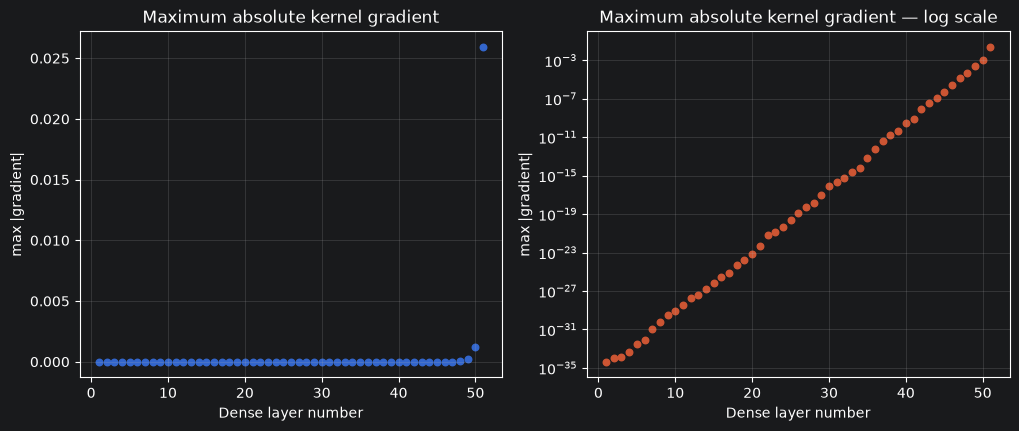

The first Dense kernel's maximum absolute gradient is **4.303e-35**, versus **2.594e-02** at the output. The logarithmic panel exposes the many-orders-of-magnitude attenuation that is hidden near zero on the linear scale.

In [25]:
gradient_figure, gradient_axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4.5),
)
gradient_axes[0].scatter(
    x=layer_numbers,
    y=maximum_absolute_gradients,
    s=22,
    color="#3366CC",
)
gradient_axes[0].set(
    title="Maximum absolute kernel gradient",
    xlabel="Dense layer number",
    ylabel="max |gradient|",
)
gradient_axes[0].grid(visible=True, alpha=0.25)

gradient_axes[1].scatter(
    x=layer_numbers,
    y=np.maximum(
        maximum_absolute_gradients,
        np.finfo(np.float64).tiny,
    ),
    s=22,
    color="#CC5533",
)
gradient_axes[1].set(
    title="Maximum absolute kernel gradient — log scale",
    xlabel="Dense layer number",
    ylabel="max |gradient|",
    yscale="log",
)
gradient_axes[1].grid(visible=True, alpha=0.25, which="both")
save_figure(figure=gradient_figure, file_name="deep_gradient_profile.png")
plt.show()

display(
    Markdown(
        f"The first Dense kernel's maximum absolute gradient is "
        f"**{first_layer_maximum_gradient:.3e}**, versus "
        f"**{last_layer_maximum_gradient:.3e}** at the output. "
        "The logarithmic panel exposes the many-orders-of-magnitude attenuation "
        "that is hidden near zero on the linear scale."
    )
)

In [26]:
quality_gate_failures = [
    metric_record
    for metric_record in METRIC_RECORDS
    if not bool(metric_record["passed"])
]
if quality_gate_failures:
    LOGGER.error("Quality gate failures: %s", quality_gate_failures)
    raise AssertionError(f"Quality gates failed: {quality_gate_failures}")

metrics_payload = {
    "output_directory": str(OUTPUT_DIRECTORY.resolve()),
    "hardware": {
        "cpu": "Intel Core Ultra 7 165H",
        "logical_threads": os.cpu_count(),
        "memory_gib": 63.45,
        "gpu": "Intel Arc Pro integrated graphics",
        "gpu_reported_adapter_memory_gib": 2.0,
        "tensorflow_devices": [
            device.name for device in tf.config.list_logical_devices()
        ],
        "execution_strategy": "Native Windows TensorFlow CPU with oneDNN",
    },
    "quality_metrics": METRIC_RECORDS,
    "timings": TIMING_RECORDS,
    "function_1_comparison": function_1_results,
    "function_2_comparison": function_2_results,
    "function_3_comparison": function_3_results,
    "sine_comparison": sine_model_results,
    "gradients": gradient_records,
    "figures": [str(figure_path.resolve()) for figure_path in FIGURE_PATHS],
}
metrics_json_path = OUTPUT_DIRECTORY / "metrics.json"
with metrics_json_path.open(mode="w", encoding="utf-8") as metrics_file:
    json.dump(
        obj=metrics_payload,
        fp=metrics_file,
        indent=2,
    )

# Export all result tables, including balanced accuracy, on every notebook run.
metrics_excel_path = OUTPUT_DIRECTORY / "metrics_with_balanced_accuracy.xlsx"
with pd.ExcelWriter(path=metrics_excel_path, engine="openpyxl") as metrics_writer:
    for sheet_name, table_records in {
        "Quality metrics": METRIC_RECORDS,
        "Timings": TIMING_RECORDS,
        "Function 1": function_1_results,
        "Function 2": function_2_results,
        "Function 3": function_3_results,
        "Sine comparison": sine_model_results,
        "Gradients": gradient_records,
    }.items():
        pd.DataFrame(data=table_records).to_excel(
            excel_writer=metrics_writer,
            sheet_name=sheet_name,
            index=False,
        )
exported_metrics_frame = pd.read_excel(
    io=metrics_excel_path, sheet_name="Quality metrics"
)
exported_balanced_accuracy = exported_metrics_frame.loc[
    exported_metrics_frame["metric"] == "test_balanced_accuracy", "value"
]
assert exported_balanced_accuracy.size == 1
np.testing.assert_allclose(
    actual=exported_balanced_accuracy.to_numpy(),
    desired=mnist_test_balanced_accuracy,
    rtol=1e-12,
)
LOGGER.info("Metrics Excel: %s", metrics_excel_path.resolve())

assert metrics_json_path.exists()
assert len(FIGURE_PATHS) >= 10
assert all(figure_path.exists() for figure_path in FIGURE_PATHS)
LOGGER.info("All %d quality gates passed", len(METRIC_RECORDS))
LOGGER.info("Metrics JSON: %s", metrics_json_path.resolve())
LOGGER.info("Timestamped output directory: %s", OUTPUT_DIRECTORY.resolve())

display(
    pd.DataFrame(data=METRIC_RECORDS).loc[
        :,
        ["stage", "experiment", "metric", "value", "threshold", "passed"],
    ]
)
display(
    Markdown(
        f"**Verification complete.** All quality gates passed. "
        f"Artifacts are in `{OUTPUT_DIRECTORY.resolve()}`. "
        f"Excel results, including balanced accuracy: `{metrics_excel_path.name}`."
    )
)

2026-09-06 18:12:56,466 | INFO | going_deeper | Metrics Excel: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\metrics_with_balanced_accuracy.xlsx
2026-09-06 18:12:56,469 | INFO | going_deeper | All 11 quality gates passed
2026-09-06 18:12:56,470 | INFO | going_deeper | Metrics JSON: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329\metrics.json
2026-09-06 18:12:56,471 | INFO | going_deeper | Timestamped output directory: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329


,stage,experiment,metric,value,threshold,passed
0,Function 1,batch_32_units_3,test_mse,1.233770e-05,0.001000,True
1,Function 2,3x3,test_mse,4.021663e-08,0.000100,True
2,Function 3,tanh_depth_4,test_mse,5.072328e-05,0.010000,True
3,Sine neuron,informed initialization,test_mse,6.897751e-10,0.000100,True
4,MNIST,dense_128_64,test_loss,8.199714e-02,NaN,True
5,MNIST,dense_128_64,test_accuracy,9.764000e-01,0.970000,True
6,MNIST,dense_128_64,test_balanced_accuracy,9.762394e-01,NaN,True
7,MNIST,dense_128_64,macro_ovr_auc,9.995362e-01,0.995000,True
8,Identity,1 hidden layer × 3 sigmoid,test_mse,1.143148e-05,0.001000,True
9,Identity,50 hidden layers × 3 sigmoid,test_mse,8.184118e-02,0.000011,True


**Verification complete.** All quality gates passed. Artifacts are in `C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\exercise\outputs\going_deeper_20260906_180329`. Excel results, including balanced accuracy: `metrics_with_balanced_accuracy.xlsx`.